<a href="https://colab.research.google.com/github/Dan-nisimi/Machine-Learning-ADVANCE-SCRIPTS/blob/main/Feature_Engineering_%26_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FEATURE ENGINEERING AND MODEL EVALUATION

In [ ]:
#Feature engineering is the process of transforming raw data into meaningful inputs that can be used by a machine learning model.

#It is important because:
#improves model accuracy
#reduces the need for manual feature selection
#reduces the risk of overfitting and model complexity
#Ensures model interpretability
#Handles data challenges such as missing values, outliers, and imbalanced datasets

#Key Applications
# Finance: Fraud detection and risk management
# Healthcare: Disease prediction
#E-commerce: Activity logs turn into purchase decisions

#Categorucal Features
#1. One-hot encoding
#2. Label encoding

#Numerical  Features
#1. Normalization
#2. Standardization


#Feature Engineering Techniques
#1. Feature scaling : Ensures features are on the same scale and contributes to the mode;l equally
#e.g minmax scaling or standardization
#2.

#3. Encoding : Converts categorical features into numerical ones
#e.g one-hot encoding or label encoding

#4. Transformarion: Applies mathematical operations to transform raw data into more suitable format for a machine learning model
# e.g log transformation, square root transformation

#5. Feature selection: Selects the most relevant features that contribute to the model's performance
#2.  statistical tests, correlation analysis, recureive fearure elimination, and wrapper methods



In [ ]:
import pandas as pd

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display dataset Information
print("Dataset Info: \n")
print(df.info())

# # Preview the first few rows
print("\n Dataset Preview:\n")
print(df.head())

# # Seperate features
categorical_features = df.select_dtypes(include=["object"]).columns # Display category features
numberical_features = df.select_dtypes(include=["int64", "float64"]).columns# Display numerical features

print("\nCategorical Features: ", categorical_features.tolist())# Display numerical features
print("\nNumerical Features: ", numberical_features.tolist()) # Display categorical features

# Display summary of categorical features
print("\n Categorical Feature Summary:\n")
for col in categorical_features:
    print(f"{col}:\n", df[col].value_counts(), "\n")

# Display Summary of numerical features
print("\n Numerical Feature Summary:\n")
print(df[numberical_features].describe())

Dataset Info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

 Dataset Preview:

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         

# DATA SCALING AND NORMALIZATION

In [ ]:
#Scaling and normalization: These are preprocessing techniques that transform the numerical features in a dataset to a common scale or distribution.

#Its important because:

# Improves model accuracy and algorithm performance
# Reduces the risk of overfitting and model complexity
# Ensures model interpretability and ensure fair comparison between features with different scales and distributions
# Handles data challenges such as missing values, outliers, and imbalanced datasets
#Stabilizes training

#Methods
#1. Min-max Scaling: Transforms numerical features to a range between 0 and 1
#Ensures features are on the same scale and contributes equally to the model. Use cases include:
#KNN or neural network. Limitations are sensitivity to outliers and imbalanced datasets as extreme values can distort scale.

#2. Standardization (Z-score scaling): Transforms numerical features to have a mean of 0 and a standard deviation of 1
#Ensures a standard normal distribution and contributes equally to the model. Use cases include:
#Linear regression, PCA, SVM, and decision trees. Handles outliers better.

#When To Use Scaling and Normalization for Different Algorithms

#Algorithms that requires caling are
# - Dsitance based algorithms : KNN, SVM, K-means clustering. They rely on distance metrics that are sensitive to feature magnitude
# - Gradient based algorithms : Linear regression, Logistic regression, Neural networks. Scaking accelerates convergence during training

#Algorithms Less Sensitive to Training
# - Tree based algorithms : Decision trees, Random forests, Gradient boosted trees. These algorithms split data based on thresholds
# and are not sensitive to feature magnitude


In [ ]:
#EX1: Apply min-max saling and standardization to a dataset using scikit-learn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

# Load Iris dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)#data.data is a numpy array of shape (150, 4) containing the feature values
y = data.target #data.target is a numpy array of shape (150,)
#containing the class labels (0, 1, or 2) for each sample in the dataset

# Display dataset Information
print("Dataset Info:")
print(X.describe())
print("\n Target Classes:", data.target_names)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train k-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)#n_neighbors is the number of neighbors to consider when classifying a sample
knn.fit(X_train, y_train) #fit method is used to train the model on the training data

# Predict and evaluate
y_pred = knn.predict(X_test)
print("Accuracy Without Scaling:", accuracy_score(y_test, y_pred))

# Apply Min-Max Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# SPlit scaled data
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


#Ex 2: Observe the effects of scaling on model performance by training a k-NN classifier before and after scaling

# Train k-NN classifier on scaled data
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train_scaled)

# Predict and evaluate
y_pred_scaled = knn_scaled.predict(X_test_scaled)
print("Accuracy with Min-Max Scaling:", accuracy_score(y_test_scaled, y_pred_scaled))

# Apply Standardization
scaler = StandardScaler()
X_stand = scaler.fit_transform(X)

# SPlit standardized data
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_stand, y, test_size=0.2, random_state=42)

# Train k-NN classifier on standardized data
knn_stand = KNeighborsClassifier(n_neighbors=5)
knn_stand.fit(X_train_std, y_train_std)

# Predict and evaluate
y_pred_std = knn_stand.predict(X_test_std)
print("Accuracy with Standardization:", accuracy_score(y_test_std, y_pred_std))







# ENCODING CATEGORICAL VARIABLES

In [ ]:
#Categorical variables are labels that do not have a numeric value, but rather represent categories or groups of values.

#Examples of categorical variables include gender (Binary), race, color (Multclass), and education level.

#Categorical variables must be transformed into numerical variables before they can be used in machine learning algorithms.

#- One hot encoding is a common method for converting categorical variables into numerical variables.
#It creates a new column for each category and sets the value to 1 if the category is present in the original variable and 0 otherwise.
#example: Feature: Color = ["Red", "Blue", "Green"]
#Red = [1, 0, 0]
#Blue = [0, 1, 0]
#Green = [0, 0, 1]

#Applications
#Categorical features with a small number of unique categories
#Tree-based models, such as decision trees and random forests, logistic regression and neural network

#2 : Label Encoding
#Label encoding is a method for converting categorical variables into numerical variables.
#It assigns a unique integer value to each category and uses these values as the input features for machine learning algorithms.
#example: Feature: Color = ["Red", "Blue", "Green"]
#Red = 1
#Blue = 2
#Green = 3

#Applications for label encoding are
#Ordinal features  where the order of the categories matters
#Can introduce unintended ordinal relationships for nominal features

# Limitations
#- Can mislead algorithms into interpreting categories as ordered, especially when the variable is nominal
#- Does not handle missing values

#Dealing with High-cardinality categorical features
#- High cardinality features contain a large number of unique categories
#- Challenges include
#2. Spare
#1.Dimensionality: High cardinality features can increase the dimensionality of the dataset, leading to overfitting
#2. Sparse represengtation: High cardinality features can lead to sparse representations, which can cause the model to overfit to the training data

#Solutions are
# - Frequency encoding : Replace category with their occuring frequency on the dataset
#Example: city = ["New York", "London", "Paris", "New York", "London"]
#Encoded will be:
#New York = 2
#London = 2
#Paris = 1

#- Target encoding : Replace category with their average target value on the dataset
#Example: city = ["New York", "London", "Paris", "New York", "London"]
#Encoded will be:
#New York = 2
#London = 2
#Paris = 1

##When to use different coding technique

# - One hot : Nominal featres with small number of unique categories
-# Label encoding : Nominal feartues with large number of unique categories e.g tree based models
-# Frequency encoding : High cardinality features in both regression and classification
-# Target encoding : High cardinality features in supervsised learning task


In [ ]:
#Ex: Apply One-hot encoding and label encoding to a dataset with categorical variables
# Experiment with different encoding techniques and observe their impact on a model performance

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Display dataset information
print("Dataset Info:")
print(df.info())

# Preview the first few rows
print("\n Dataset Preview:")
print(df.head())

# Applt One-Hot Encoding
df_one_hot = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
#drop_first is used to remove the first column
#pd.get_dummies is used to convert categorical variables into numerical variables

# Display encoded dataset
print("\n One-Hot Encoded dataset:")
print(df_one_hot.head())

# Apply Label Encoding
label_encoder = LabelEncoder() #label encoder is used to convert categorical variables into numerical variables
df['Pclass_encoded'] = label_encoder.fit_transform(df['Pclass'])

# Display encoded dataset
print("\n Label Encoded Dataset:")
print(df[['Pclass', 'Pclass_encoded']].head())

# APply Frequency Encoding
df['Ticket_frequency'] = df['Ticket'].map(df['Ticket'].value_counts())

# Display frequency encoded feature
print("\n Frequence ENcoded Feature: ")
print(df[['Ticket', 'Ticket_frequency']].head())

X = df_one_hot.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin', 'Age'])
y = df['Survived']


# SPlit dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy with One-Hot Encoding:", accuracy_score(y_test, y_pred))


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

 Dataset Preview:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0  

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# FEATURE SELECTION TECHNIQUES

In [ ]:
#Feature selection is the process of identifying the most relevant features (input variables) in a dataset for a given task while discarding the less important ones.

#Why is it important?
#- Improves model performance by reducing overfitting
#- Reduces the dimensionality of the dataset
#- Improves interpretability of the model
#- Increases computational efficiency

#When to use Feature Selection
#- High-dimensional datasets
#- Overfitting
#- Feature redundancy
#- Feature correlation
# - Reducing complexity

#Techniques

#- Filter methods : Evaluate features based on their correlation with the target variable. It analyzes statistical properties
#in relation to the feature. E.g Correlation coefficient|Mutual information.
#It is used when we have to conduct quick evaluation of features before training the model

#- Wrapper methods: Iteratively train models with different subsets of features and evaluate their performance.
#examples : Forward seklection| Backward elimination.
#Useful when features are important but computationally expensive

#- Embedded methods: Performs feature selection as part of the model training process.
#E.g : Lasso| Ridge regression| Decision tree| Random forest
#Useful when training tree based models on a regularized dataset

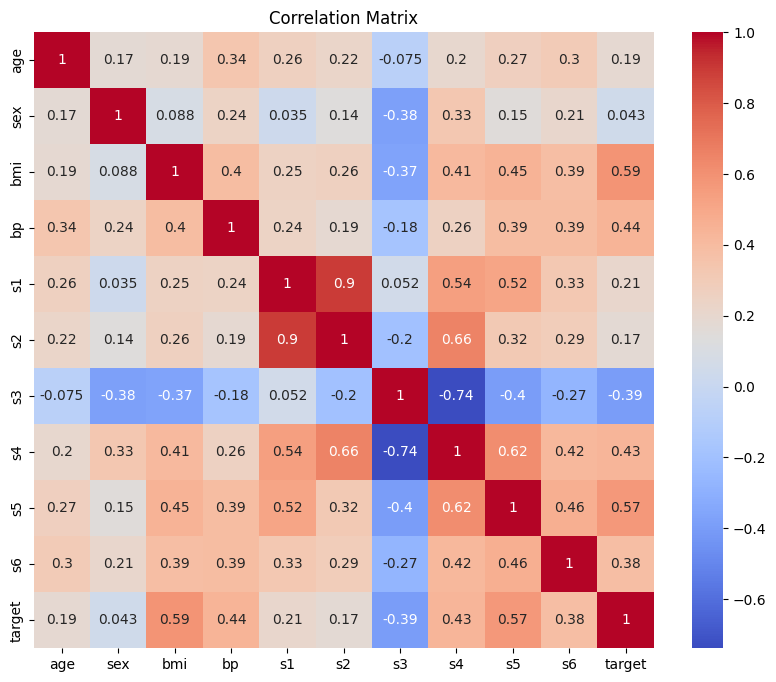

Features Most Correlated with Target:
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64
Mutual Information Scores:
  Feature  Mutual Information
2     bmi            0.176215
8      s5            0.143957
7      s4            0.118424
9      s6            0.110568
4      s1            0.065732
6      s3            0.063745
3      bp            0.059601
1     sex            0.018425
5      s2            0.015766
0     age            0.000000
Feature Importance from Random Forest:
  Feature  Importance
8      s5    0.315629
2     bmi    0.276249
3      bp    0.087085
9      s6    0.070775
0     age    0.057496
5      s2    0.055368
6      s3    0.051191
4      s1    0.047251
7      s4    0.027056
1     sex    0.011901


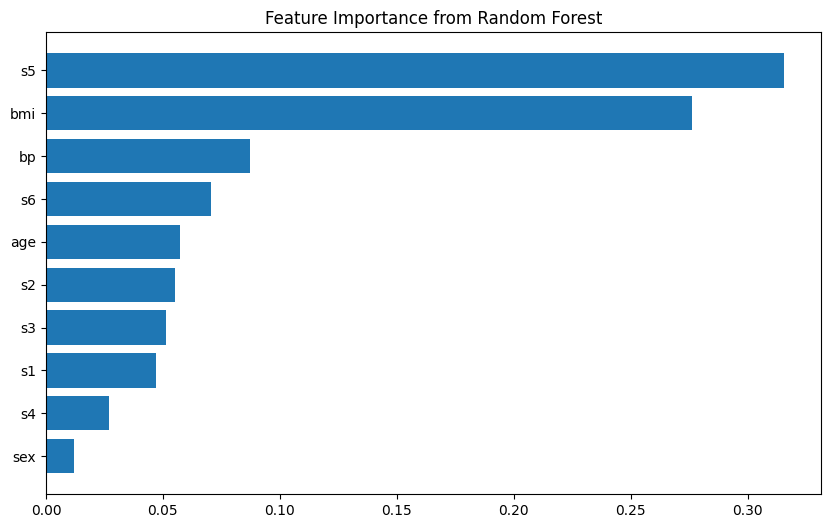

In [ ]:
#Ex: Use correlation and mutual information to select important features from a dataset

from sklearn.datasets import load_diabetes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

# Load the dataset
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)#feature_names is used to get the names of the features in the dataset
df['target'] = data.target # target is used to get the target variable in the dataset

# Display Dataset information
# print(df.head())
# print(df.info())

# Calculate correlation matrix
correlation_matrix = df.corr()

#Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Select features with high correlation to the target
correlated_features = correlation_matrix['target'].sort_values(ascending=False)
#.sort_values() is used to sort the values in descending order
print("Features Most Correlated with Target:")
print(correlated_features)

# Seperate featured and target
X = df.drop(columns=['target']) #drop is used to remove the target variable
y = df['target']

# Calculate mutual information
#Mutual information is a measure of the dependence between two random variables X and Y given a third random variable Z or set of random variables Z = {Z1, Z2, ..., Zn}

#mutual_info_regression is used to calculate the mutual information between the features and the target variable
mutual_info = mutual_info_regression(X, y)

# Create a Dataframe for better visualization

#mutual_info is used to get the mutual information between the features and the target variable
mi_df = pd.DataFrame({'Feature': X.columns, "Mutual Information": mutual_info})
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False) #sort_values is used to sort the values in descending order

print("Mutual Information Scores:")
print(mi_df)

#2. Apply a tree based model(e.g a random forest ) to identify the most important features
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Train a Random Forest Model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Get feature importance
feature_importance = model.feature_importances_ #feature_importances is used to get the importance of the features in the model
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance from Random Forest:")
print(importance_df)

# PLot feature importance
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance']) #barh is used to create a horizontal bar chart
plt.gca().invert_yaxis() #gca is used to get the current axis and invert_yaxis is used to invert the y axis
plt.title("Feature Importance from Random Forest")
plt.show()

# CREATING AND TRANSFORMING FEATURES

In [ ]:
#Feature creation is the process of generating new features from existing ones to improve the performance of a machine learning model.
#Examples of feature creation include:

#- Date-Time- Features : Extract features from date and time attributes e.g day of the week, month, year. Use case is predicting sales trend where seasonality is important
#- Text Features : Extract features from text data
#- Image Features : Extract features from image data
#- Geospatial Features : Extract features from geospatial data
# - Interaction Features : Create new features by combining existing feature e.g Multiplying area and price per square foot for real estate.
# - Aggregations : Create new features by aggregating existing features e.g Grouping transactions by customer and calculating average transaction amount.

#Importance of feature creation
# - Adds domain knowledge to the dataset
# - Captures hidden patterns and trends not evident in the original features

#Feature transformation is the process of modifying existing features to improve the performance of a machine learning model.
#Examples of feature transformation include:

#Logarithmic Transformation : Transforming a feature by taking the logarithm of its values. It reduces skewness and improves model performance

#Square Root Transformation : Transforming a feature by taking the square root of its values. Moderately reduces skewness and improves model performance, used for count data

#Polynomial transformation : Transforming a feature by raising its values to a power. It captures non-linear relationships between features and improves model performance

#Importance of feature transformation
# - Improves model performance by helping to fit non-linear relationships between features
# - Makes distributions more normal-like, aiding algorithms that assume normality

#Importance of Feature Transformation in Non-linear relationships
#- Transformation allows linear models to handle non-linear relationships between features.
#e.g Logarithmic transformation can be used to stabilize variance and handle skewness in data.
# Polynomial transformation enable linear regression models to model quadratic patterns in data.


In [ ]:

from google.colab import files

# Create an upload button
uploaded = files.upload()

Saving bike_sharing_daily.csv to bike_sharing_daily.csv


In [ ]:
#EX : Create new features from a date column (e.g day of the week, month, year)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load Bike Sharing Dataset
df = pd.read_csv("bike_sharing_daily.csv")

#Display dataset information
print("Dataset Info:")
print(df.info())

#Preview the first few rows
print("\n Dataset Preview:")
print(df.head())

# Convert dteday to datetime
df['dteday'] = pd.to_datetime(df['dteday'])# pd.to_datetime is used to convert the dteday column to datetime e.g 2011-01-01

# Create new features
df['day_of_week'] = df['dteday'].dt.day_name() #day_name is used to get the day of the week
df['month'] = df['dteday'].dt.month #month is used to get the month of the year
df['year'] = df['dteday'].dt.year #year is used to get the year

# Display the enw features
print("\n New Features Derived from Date Column")
print(df[['dteday', 'day_of_week', 'month', 'year']].head())

#Apply polynomial transformation to a dataset and compare the model performance before and after the transformation

import pandas as pd
# Select feature and target
X = df[['temp']]
y = df['cnt']

# Apply polynomial transformation
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Display the tranformed feature
print("\n Original and Polynomial Features")
#X_poly is used to get the transformed features, e.g temp and temp^2
print(pd.DataFrame(X_poly, columns=['temp', 'temp^2']).head())

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_poly_train, X_poly_test = train_test_split(X_poly, test_size=0.2, random_state=42)

# Train and evaluate model with original features
model_original = LinearRegression()
model_original.fit(X_train, y_train)
y_pred_original = model_original.predict(X_test)
mse_original = mean_squared_error(y_test, y_pred_original)

# Train and evaluate model with polynomial features
model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)
y_pred_poly = model_poly.predict(X_poly_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)

# COmpare results
print(f"MSE original: {mse_original:.2f}")
print(f"MSE Polynomial: {mse_poly:.2f}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

 Dataset Preview:
   instant      dteday  season  yr  mnth  holiday  week

#MODEL EVALUATION METRICS

In [ ]:
#Regression Evaluation Metrics

#MAE : Mean Absolute Error: The average absolute difference between the predicted and actual values without regard to the direction
#Use case: When all errors are equally important

#MSE : Mean Squared Error: The average of the squared differences between the predicted and actual values
#Use case: Penalizes larger errors more heavily than smaller errors, making it sensitive to outliers
### Layman Explanation:
# **Mean Squared Error (MSE)** is like a way to measure how far off your guesses (predictions) are from the real answers.
# It looks at the difference between what you predicted and the actual value, squares those differences (to make big mistakes stand out more),
# and averages them. The smaller the MSE, the better your guesses!
# ### For a Five-Year-Old:
# Imagine you're guessing how many candies are in a jar. MSE looks at how wrong your guesses are by comparing them to the actual number of candies.
#  It also gives bigger importance to big mistakes by squaring them (it's like saying, "Whoa! That was way off!"). Then it takes the average of all
#  your guesses to see how good you were overall. Smaller MSE means you’re doing a great job! It’s like your candy-guessing scorecard!

#RMSE : Root Mean Squared Error: The square root of the mean squared error, providing errors in the same unit as the target variable
#Use case : A common metric for interpretability in real-world units

#R2 : R-squared measures how well the model explains the variability (how much the data deviates from the mean)or changes in the target variable
# A higher R-squared means the model better fits the data, while a lower R-squared means the model isn't very good at explaining the changes in the data.
# Think of R-squared as a measure of how well your regression model captures the story of your data. Imagine a classroom: You're trying to predict students'
# test scores based on the number of hours they study. Perfect Model: If your model perfectly predicts every student's score based on study hours, R-squared would be 1 (or 100%).
#No Prediction: If your model does a terrible job and doesn't help at all, R-squared would be 0 (or 0%).

#Classification Evaluation Metrics

#Accuracy: The proportion of correctly predicted observations out of the total number of observations. Suitable for balanced datasets but misleading for imbalanced datasets

#Precision: The proportion of correctly predicted positive observations (true positives) out of the total number of predicted positive observations
#Important when false positives are costly e.g spam detection

#Recall(sensitivity): The proportion of correctly predicted positive observations out of the total number of actual positive observations.
# Useful in situations where false negatives are costly e.g medical diagnosis

#F1-Score : The harmonic mean of precision and recall, providing a balanced measure of model performance. Useful for imbalanced datasets

#ROC-AUC : The area under the receiver operating characteristic (ROC) curve, which is a measure of model performance in binary classification problems
#I.E model ability to distinguish between classes. Useful for evaluating binaary classifers

#Understanding when to use these metrics
#- Regression
#- Use MAE for errors that are equally important, MSE for errors that are penalized more heavily, RMSE for errors in the same unit as the target variable, R2 to explain variance
# but not as a sole performance metric

#- Classification :
#- Use Accuracy for balanced datasets, Precision and Recall for imbalanced datasets, depending on the problem's focus (e.g minimizing false +ve or -ve)
#- F1-Score for balanced evaluation of precision and recall, ROC-AUC for overall model performance in binary classification problems



###Classification Model Evaluation Example

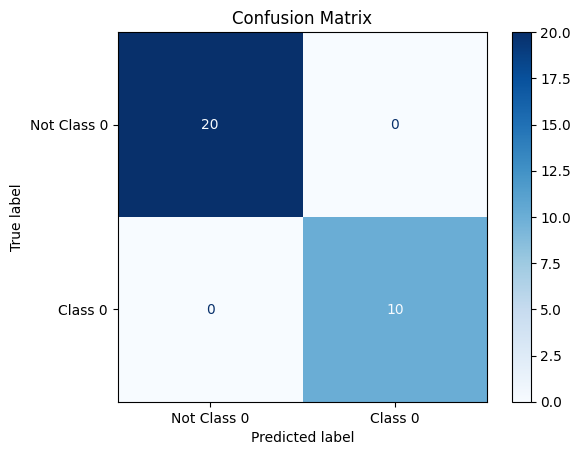


 Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
#EX 1: Classification Model Evaluation
#Objective: Train a classification model, calculate confusion matrix and interpret precision, recall and f1-score

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load dataset
data = load_iris()
X = data.data
y = (data.target == 0).astype(int) #.astype(int) is used to convert the target variable to integer

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_predict = model.predict(X_test)

# Confusion Matrix is used to evaluate the performance of a classification model by comparing the predicted class labels with the actual class labels
cm = confusion_matrix(y_test, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Class 0", "Class 0"])#ConfusionMatrixDisplay is used to display the confusion matrix
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Classification metrics
print("\n Classification Report: ")
print(classification_report(y_test, y_predict))

###Regression Model Evaluation example

In [ ]:
#Train a regression model and evaluate its performance using MAE, MSE and R2

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2-Score(R2): {r2:.2f}")

Mean Absolute Error (MAE): 0.53
Mean Squared Error (MSE): 0.56
R2-Score(R2): 0.58


# CROSS VALIDATION AND HYPERPARAMTER TUNING

In [ ]:
#Cross validation is a technique used to evaluate the performance of a machine learning model in generalizing to an independent dataset
#It does this by splitting the dataset into a training and testing set, and then training the model on the training set and evaluating its performance on the testing set

#Types

#K-fold cross validation :
#- Divides the dataset into k-fold of equal parts
#- Trains the model on k-1 parts and evaluates its performance on the remaining part
#- This process is repeated k times and the average performance is computed

#Stratified cross validation :
#- Ensures that each fold has an equal distribution of classes in the training or original set
#- Useful for imbalanced datasets

#Leave-one-out cross validation :
#- Uses a single data point for validation and the rest for training
#- Repeated for each data point in the dataset

#Hyperparameter Tuning
#These are paramters (e.g learning rate, regularization strength) that are not learned by the model and are set before traning the model.
#Tuning them can help improve the model's performance by finding the best combination of hyperparameters that work best for the given dataset and problem type

#TECHNIQUES OF HYPERPARAMETER TUNING
#Grid Search :
#- Creates a grid of hyperparameter values to search through
#- Trains the model on each combination of hyperparameters in the grid
#e.g learning rate = [0.1, 0.01, 0.001] and regularization strength = [0.1, 0.01, 0.001]
#- The model with the best performance on the validation set is selected

#Random search :
#- Creates a random sample of hyperparameter values from predefined space
#- Trains the model on each combination of hyperparameters in the sample
#- The model with the best performance on the validation set is selected
# More efficient than grid search when the number of hyperparameters is large

#Importance of hyperparameter tuning
#- Improves model performance by optimizing critical settings and its ability to generalize to new data
#- Reduces overfitting and underfitting by selecting the best hyperparameters configuration
#- Improves generalization

#Importance of Tunning Hyperparameters for model performance
#- Without tunning hyperparameters, model may overfit or underfit to the training data and may not capture the underlying patterns
# - Without tunning, model might not generalize well to new data and may not perform well in real-world scenarios


 code defines a dictionary called param_grid that is used for hyperparameter tuning, specifically for a Random Forest model in this case. Here's what each part means:

**param_grid**: This is the name of the dictionary. It's essentially a container holding the hyperparameters and their possible values that you want to try out.

Keys ('n_estimators', 'max_depth', 'min_samples_split'): These are the names of the hyperparameters you're going to tune for your Random Forest model.

**n_estimators**: This represents the number of trees in your Random Forest. More trees often lead to better performance but can increase computation time. Here, you're considering 50, 100, and 200 trees.

**max_depth**: This controls the maximum depth (number of levels) of each tree in the forest. Deeper trees can capture more complex relationships but might overfit. 'None' means there's no limit to the depth. You're trying no limit, a depth of 10, and a depth of 20.

**min_samples_split**: This specifies the minimum number of samples required to split an internal node of a tree. A higher value can prevent overfitting by making the trees less complex. You're trying 2, 5, and 10 samples.
Values ([50, 100, 200], [None, 10, 20], [2, 5, 10]): These lists contain the different values you want to test for each hyperparameter. For example, for n_estimators, you'll try 50, then 100, then 200.

In essence, this param_grid is telling the hyperparameter tuning process (likely using GridSearchCV) to try all possible combinations of these values for the specified hyperparameters. It will then select the combination that gives the best performance on your data (usually measured using cross-validation).

In [ ]:
#Project

#Perform end-to-end feature engineering, model evaluation and hyperparameter tuning on a dataset

#Task 1: Feature Engineering
#Objective: Perform feature engineering on a dataset to create new features that improve the performance of a machine learning model

import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Loading Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select relevant features
df = df[['Pclass','Sex','Age','Fare','Embarked','Survived']]

# Handle missing values
#df.method({col: value}, inplace=True)
df.fillna({'Age':df['Age'].median()}, inplace=True)#median() is used to get the median value of the column Age and replace the missing values with it
df.fillna({'Embarked':df['Embarked'].mode()[0]}, inplace=True) #mode()[0] is used to get the most frequent value of the column Embarked and replace the missing values with it

# Define features and target
X = df.drop(columns=['Survived']) #df.drop(columns=['Survived']) is used to remove the target variable from the features
y = df['Survived'] #df['Survived'] is used to select the target variable

# Apply feature scaling and encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age', 'Fare']),
        ('cat', OneHotEncoder(), ['Pclass', 'Sex', 'Embarked'])
    ]
) #ColumnTransformer is used to apply feature scaling and encoding (encoding is used to convert categorical variables to numerical variables) to the features
#onehotencoder is used to convert categorical variables to numerical variables
#standardscaler is used to scale the numerical variables to a mean of 0 and a standard deviation of 1

X_preprocessed = preprocessor.fit_transform(X) #preprocessor.fit_transform(X) is used to apply the feature scaling and encoding to the features


#Task 2: Train and Evaluate Model
#Objective: Evaluate the performance of a machine learning model on a dataset using appropriate metrics

# Train and evaluate Logistic Regression
log_model = LogisticRegression()
log_scores = cross_val_score(log_model, X_preprocessed, y, cv=5, scoring='accuracy') #cross_val_score is used to evaluate the performance of the model using cross-validation
print(f"Logistic Regression Accuracy: {log_scores.mean():.2f}") #.2f is used to round the accuracy to 2 decimal places

# Train and evaluate Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf_model, X_preprocessed, y, cv=5, scoring='accuracy')
print(f"Random Forest Accuracy: {rf_scores.mean():.2f}")

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
} #n_estimators is the number of trees in the forest, max_depth is the maximum depth of the trees,
#min_samples_split is the minimum number of samples required to split an internal node


#Task 3: Apply Grid Search for Hyperparameter Tuning
#Objective: Tune hyperparameters of a machine learning model to improve its performance on a dataset

# Perform Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1 #n_jobs=-1 is used to use all available cores for parallel processing
)
grid_search.fit(X_preprocessed, y)

# Display best hyperparameters and score
print(f"Best hyperparameters: {grid_search.best_params_}")#best_params_ is used to get the best hyperparameters
print(f"Best Accuracy: {grid_search.best_score_:.2f}") #.2f is used to round the accuracy to 2 decimal places


Logistic Regression Accuracy: 0.79
Random Forest Accuracy: 0.81
Best hyperparameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best Accuracy: 0.83
